# Fusion Pipeline Mini-Overfit Dashboard (STEP 5.5)

End-to-end **technical** check: tucker slices → 4 expert models → PoE fusion → final (B,12).
NOT accuracy, NOT LOSO, NOT production training. Configure, optionally launch, then view results.

In [1]:
# === CONFIG ===
RUN         = False                 # True -> launch the script; False -> load existing results
DATA_DIR    = 'data_training_full_rebuilt'
INIT        = 'fresh'               # 'fresh' | 'step5'
MODE        = 'both'                # 'fusion_only' | 'end_to_end' | 'both'
NUM_SAMPLES = 32
EPOCHS      = 300
LR          = 1e-3
DEVICE      = 'cuda'
SEED        = 42
OUTPUT_SUB  = 'fusion_mini_overfit'   # or 'fusion_mini_overfit_step5init'
import sys, json, subprocess
from pathlib import Path
import pandas as pd, matplotlib.pyplot as plt
from PIL import Image
ROOT = Path('..').resolve(); sys.path.insert(0, str(ROOT))
OUT = ROOT/'outputs'/OUTPUT_SUB
print('output dir:', OUT)

output dir: C:\Users\medte\OneDrive\Desktop\Fusion_Model\outputs\fusion_mini_overfit


In [2]:
if RUN:
    cmd = [sys.executable, str(ROOT/'scripts/fusion/mini_overfit_fusion_pipeline.py'),
           '--data-dir', str(ROOT/DATA_DIR), '--output-dir', str(OUT),
           '--num-samples', str(NUM_SAMPLES), '--epochs', str(EPOCHS), '--lr', str(LR),
           '--device', DEVICE, '--seed', str(SEED), '--init', INIT, '--mode', MODE]
    print('running:', ' '.join(cmd)); subprocess.run(cmd, check=True, cwd=str(ROOT))
else:
    print('Loading existing results (RUN=False).')

Loading existing results (RUN=False).


## PASS/FAIL summary + gate

In [3]:
summary = json.load(open(OUT/'fusion_mini_overfit_summary.json'))
print('fusion_mini_overfit_pass:', summary['fusion_mini_overfit_pass'], '| step6_allowed:', summary['step6_allowed'])
print('fusion module:', summary['fusion_module'])
pd.read_csv(OUT/'fusion_mini_overfit_summary.csv')[['mode','status','initial_loss','final_loss','loss_reduction_ratio','reload_ok','grad_norm_experts_mean','grad_norm_fusion_mean','fail_reason']]

fusion_mini_overfit_pass: False | step6_allowed: False
fusion module: real PoEFusion base + thin trainable residual head (mini-overfit wrapper); production poe.py/fusion_model.py unchanged; EMA excluded


,mode,status,initial_loss,final_loss,loss_reduction_ratio,reload_ok,grad_norm_experts_mean,grad_norm_fusion_mean,fail_reason
0,fusion_only,FAIL,1.741758,0.589602,0.3385,True,0.000000,0.202243,loss not reduced enough (final/init=0.339)
1,end_to_end,PASS,2.178716,0.000425,0.0002,True,0.041076,0.012202,NaN


## Per-mode plots

============================== end_to_end ==============================


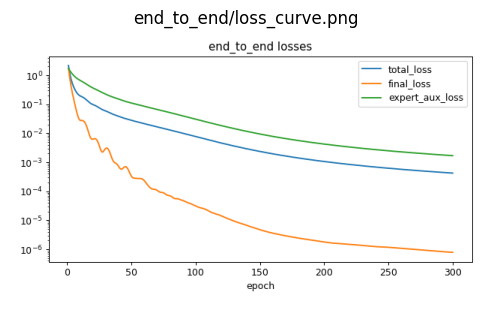

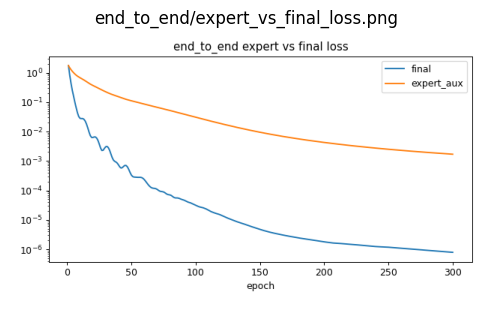

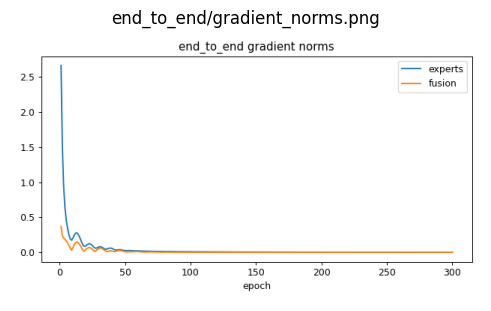

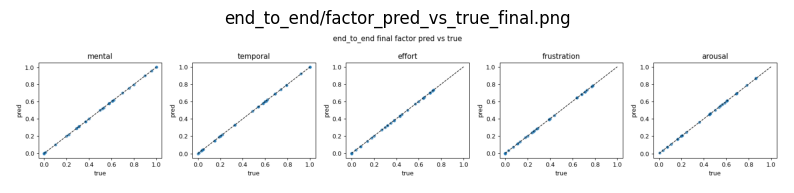

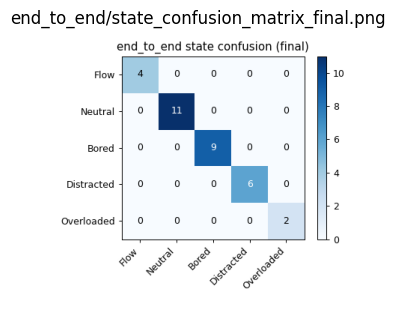

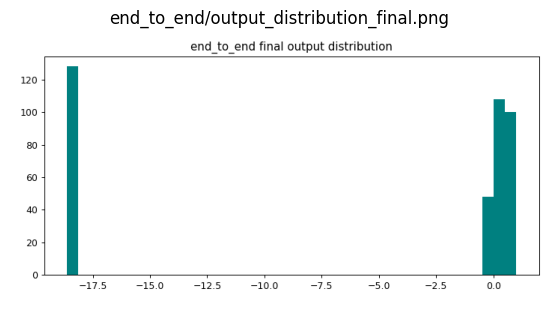

============================== fusion_only ==============================


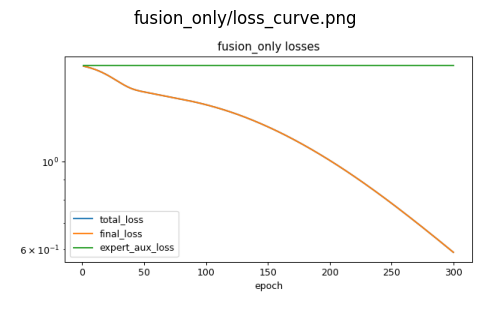

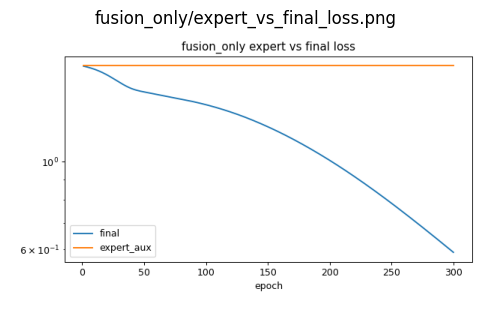

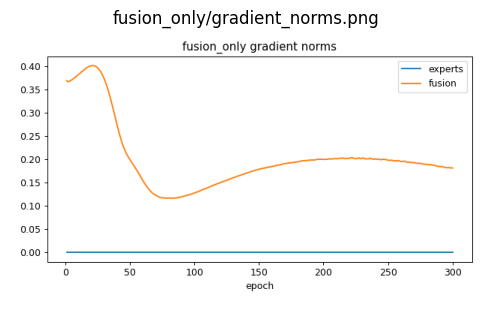

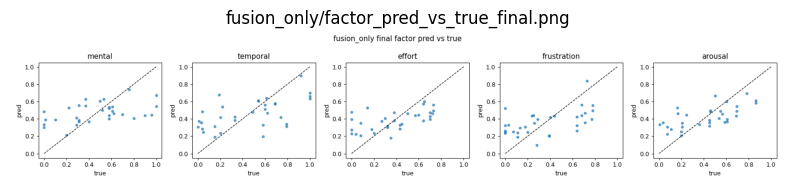

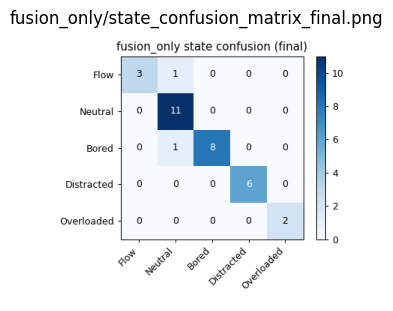

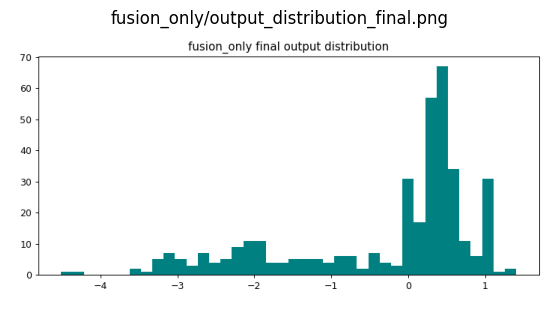

In [4]:
def show(mode):
    imgs = ['loss_curve.png','expert_vs_final_loss.png','gradient_norms.png',
            'factor_pred_vs_true_final.png','state_confusion_matrix_final.png','output_distribution_final.png']
    for im in imgs:
        p = OUT/mode/im
        if p.exists():
            plt.figure(figsize=(10,3.5)); plt.imshow(Image.open(p)); plt.axis('off'); plt.title(f'{mode}/{im}'); plt.show()
import os
for mode in [d.name for d in OUT.iterdir() if d.is_dir()]:
    print('='*30, mode, '='*30); show(mode)

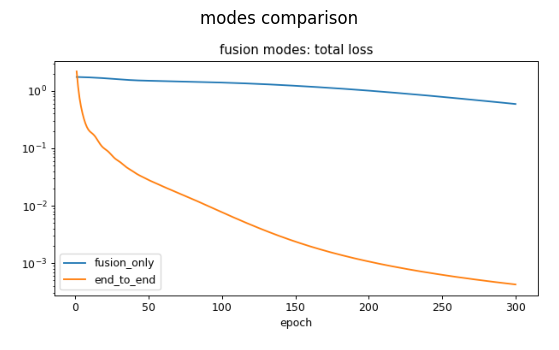

end_to_end   reload_ok=True max_abs_diff=0.00e+00
fusion_only  reload_ok=True max_abs_diff=0.00e+00


In [5]:
cmp = OUT/'fusion_modes_comparison.png'
if cmp.exists():
    plt.figure(figsize=(8,4)); plt.imshow(Image.open(cmp)); plt.axis('off'); plt.title('modes comparison'); plt.show()
for mode in [d.name for d in OUT.iterdir() if d.is_dir()]:
    rc = OUT/mode/'reload_check.json'
    if rc.exists():
        d = json.load(open(rc)); print(f'{mode:12s} reload_ok={d["reload_ok"]} max_abs_diff={d["max_abs_diff"]:.2e}')

## Interpretation
Technical learnability only. `end_to_end` is the mode that matches STEP 6 (experts+fusion trained together).
`fusion_only` over `--init fresh` (random frozen experts) is a stress test; use `--init step5` to validate the
fusion layer over competent experts. See `outputs/fusion_mini_overfit/FUSION_MINI_OVERFIT_REPORT.md`.